# Experiment: Cross-Experiment Error Analysis

This notebook reads cached analysis outputs produced by `scripts/error_analysis.py` and focuses on failure modes across `wordorder`, `size`, `orthography`, and `agreement`.

Questions:
- How much of the bag-of-words vs exact-match gap is really word-order error?
- Which other failure modes recur across experiments and models?
- Which failure modes are experiment-specific rather than generic degradation?


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
import seaborn as sns
from IPython.display import display
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "notebooks").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
OUT_DIR = PROJECT_ROOT / "notebooks" / "cache" / "error-analysis"

rows_df = pd.read_csv(OUT_DIR / "rows.csv")
metric_df = pd.read_csv(OUT_DIR / "metric_summary.csv")
failure_df = pd.read_csv(OUT_DIR / "failure_mode_summary.csv")
orth_df = pd.read_csv(OUT_DIR / "orthography_summary.csv")
example_rows = json.loads((OUT_DIR / "example_rows.json").read_text())

rows_df.shape, metric_df.shape, failure_df.shape

((20640, 24), (9, 9), (73, 5))

## Coverage

The cached table spans all currently available model outputs in the repository, including the agreement compact batches.


In [2]:
coverage_df = (
    rows_df.groupby(["exp", "fuzzy_model"])
    .size()
    .rename("rows")
    .reset_index()
    .sort_values(["exp", "fuzzy_model"])
)
display(coverage_df)
display(metric_df.sort_values(["exp", "fuzzy_model"]))

,exp,fuzzy_model,rows
0,agreement,gpt-5-mini,6720
1,agreement,gpt-5-nano,6720
2,orthography,gpt-5,360
3,orthography,gpt-5-nano,360
4,size,gpt-5,1680
5,size,gpt-5-mini,1680
6,size,gpt-5-nano,1680
7,wordorder,gpt-5,720
8,wordorder,gpt-5-nano,720


,exp,fuzzy_model,rows,exact_match,bow_match,mean_prompt_tokens,mean_completion_tokens,mean_length_delta,bow_minus_exact
0,agreement,gpt-5-mini,6720,0.468601,0.468601,1493.273512,3038.513244,-0.130506,0.000000
1,agreement,gpt-5-nano,6720,0.322619,0.322768,1493.273512,7277.348512,-0.181845,0.000149
2,orthography,gpt-5,360,0.333333,0.372222,132983.666667,7625.050000,-0.983333,0.038889
3,orthography,gpt-5-nano,360,0.000000,0.005556,132983.666667,4063.980556,5.927778,0.005556
4,size,gpt-5,1680,0.821429,0.861905,46302.790476,5712.583929,-0.114286,0.040476
5,size,gpt-5-mini,1680,0.506548,0.551786,46302.790476,5126.305952,-0.380357,0.045238
6,size,gpt-5-nano,1680,0.016667,0.320833,46302.790476,6245.759524,1.697619,0.304167
7,wordorder,gpt-5,720,0.606944,0.681944,119712.576389,6946.445833,-0.250000,0.075000
8,wordorder,gpt-5-nano,720,0.000000,0.000000,119712.576389,4688.279167,2.548611,0.000000


## Metric Gaps

A useful sanity check: the bag-of-words improvement is often much smaller than the total error mass. That means models are failing in ways other than pure permutation.


,exp,fuzzy_model,exact_match,bow_match,bow_minus_exact
0,agreement,gpt-5-mini,46.860119,46.860119,0.000000
1,agreement,gpt-5-nano,32.261905,32.276786,0.014881
2,orthography,gpt-5,33.333333,37.222222,3.888889
3,orthography,gpt-5-nano,0.000000,0.555556,0.555556
4,size,gpt-5,82.142857,86.190476,4.047619
5,size,gpt-5-mini,50.654762,55.178571,4.523810
6,size,gpt-5-nano,1.666667,32.083333,30.416667
7,wordorder,gpt-5,60.694444,68.194444,7.500000
8,wordorder,gpt-5-nano,0.000000,0.000000,0.000000


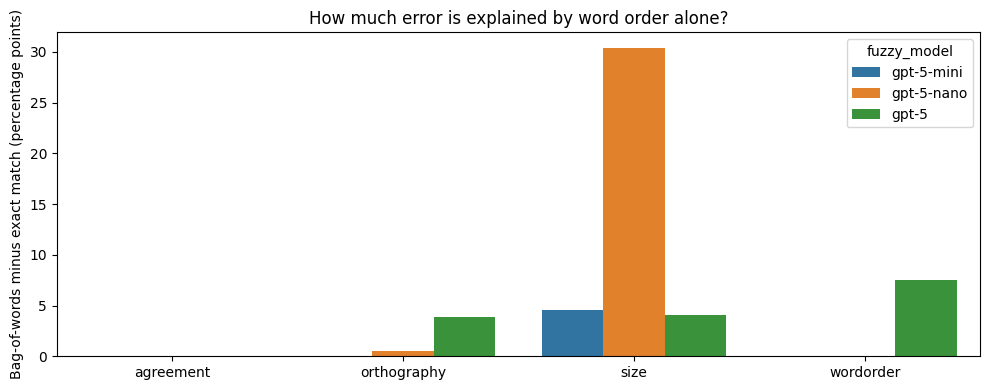

In [3]:
plot_df = metric_df.copy()
plot_df["exact_match"] *= 100
plot_df["bow_match"] *= 100
plot_df["bow_minus_exact"] *= 100

display(plot_df[["exp", "fuzzy_model", "exact_match", "bow_match", "bow_minus_exact"]].sort_values(["exp", "fuzzy_model"]))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=plot_df,
    x="exp",
    y="bow_minus_exact",
    hue="fuzzy_model",
    ax=ax,
)
ax.set_ylabel("Bag-of-words minus exact match (percentage points)")
ax.set_xlabel("")
ax.set_title("How much error is explained by word order alone?")
plt.xticks(rotation=0)
plt.tight_layout()

## Failure Modes

The main qualitative surprise from the first pass is that several strong failure modes are not just tokenization or permutation:
- `same_length_substitution`: the model outputs an in-vocabulary sentence of the right length, but swaps one or more lexical choices.
- `source_lexicon_intrusion` / `copied_source`: source-language material leaks into the answer.
- `partial_span`: the output is a clean prefix or suffix of the target, suggesting truncation or early stopping.
- `repetition_loop`: local collapse or fallback loops.
- `hallucinated_vocab`: the model invents target-side words not licensed by the grammar.


,exp,fuzzy_model,failure_mode,count,pct_within_model_exp
0,agreement,gpt-5-mini,same_length_substitution,2263,63.371605
1,agreement,gpt-5-mini,mixed_other,1266,35.452254
2,agreement,gpt-5-mini,partial_span,36,1.008121
3,agreement,gpt-5-mini,repetition_loop,5,0.140017
4,agreement,gpt-5-mini,too_long,1,0.028003
...,...,...,...,...,...
68,wordorder,gpt-5-nano,repetition_loop,49,6.805556
69,wordorder,gpt-5-nano,copied_source,28,3.888889
70,wordorder,gpt-5-nano,no_answer,13,1.805556
71,wordorder,gpt-5-nano,same_length_substitution,4,0.555556


,exp,fuzzy_model,failure_mode,count,pct_within_model_exp
0,agreement,gpt-5-mini,same_length_substitution,2263,63.371605
1,agreement,gpt-5-mini,mixed_other,1266,35.452254
2,agreement,gpt-5-mini,partial_span,36,1.008121
5,agreement,gpt-5-nano,mixed_other,2507,55.074692
6,agreement,gpt-5-nano,same_length_substitution,1880,41.300527
7,agreement,gpt-5-nano,partial_span,70,1.537786
13,orthography,gpt-5,hallucinated_vocab,176,73.333333
14,orthography,gpt-5,diacritic_drop,32,13.333333
15,orthography,gpt-5,word_order_only,14,5.833333
20,orthography,gpt-5-nano,wrong_script,160,44.444444


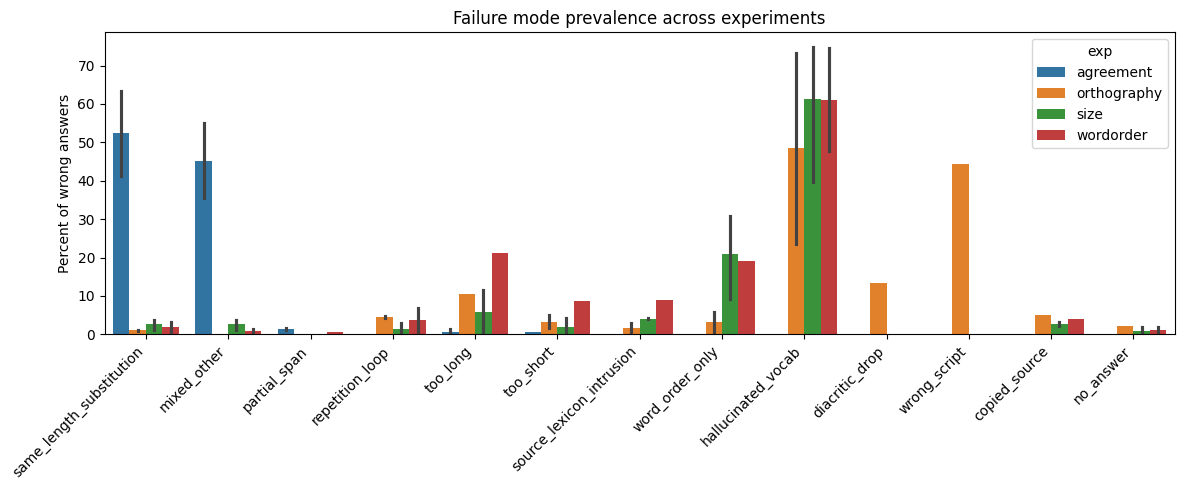

In [4]:
display(failure_df.sort_values(["exp", "fuzzy_model", "count"], ascending=[True, True, False]))

top_failure_df = (
    failure_df.sort_values(["exp", "fuzzy_model", "count"], ascending=[True, True, False])
    .groupby(["exp", "fuzzy_model"], as_index=False)
    .head(3)
)
display(top_failure_df)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=failure_df,
    x="failure_mode",
    y="pct_within_model_exp",
    hue="exp",
    ax=ax,
)
ax.set_ylabel("Percent of wrong answers")
ax.set_xlabel("")
ax.set_title("Failure mode prevalence across experiments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Orthography-Specific Effects

Orthography remains useful as a special case because it separates lexical mapping errors from script-handling failures. The cached summary tracks wrong-script and diacritic-drop rates directly.


,fuzzy_model,target_orthography,rows,exact_match,bow_match,wrong_script,diacritic_drop,too_short,same_length_substitution
0,gpt-5,cyrillic,120,0.45,0.500000,0.000000,0.000000,0.000000,0.016667
1,gpt-5,latin,120,0.55,0.616667,0.000000,0.000000,0.008333,0.008333
2,gpt-5,yiddish,120,0.00,0.000000,0.000000,0.266667,0.025000,0.000000
3,gpt-5-nano,cyrillic,120,0.00,0.008333,0.591667,0.000000,0.075000,0.016667
4,gpt-5-nano,latin,120,0.00,0.008333,0.000000,0.000000,0.066667,0.008333
5,gpt-5-nano,yiddish,120,0.00,0.000000,0.741667,0.000000,0.008333,0.000000


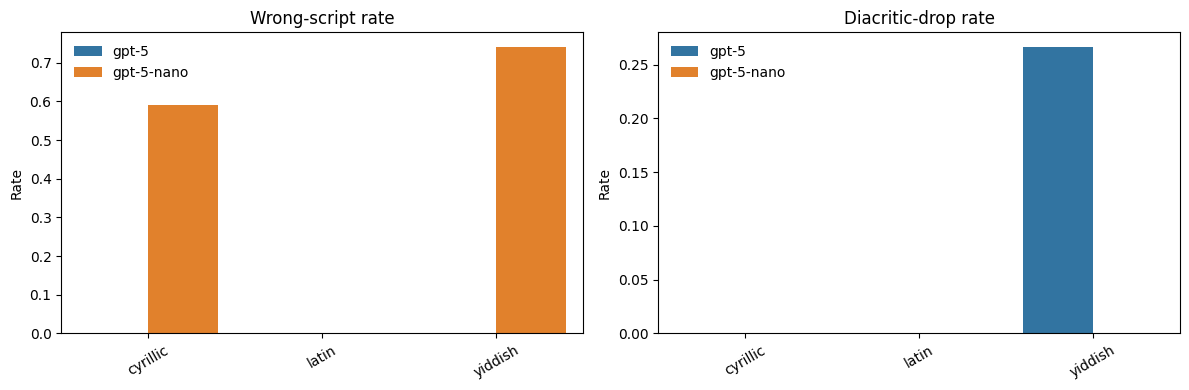

In [5]:
display(orth_df.sort_values(["fuzzy_model", "target_orthography"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
sns.barplot(data=orth_df, x="target_orthography", y="wrong_script", hue="fuzzy_model", ax=axes[0])
axes[0].set_title("Wrong-script rate")
axes[0].set_ylabel("Rate")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=orth_df, x="target_orthography", y="diacritic_drop", hue="fuzzy_model", ax=axes[1])
axes[1].set_title("Diacritic-drop rate")
axes[1].set_ylabel("Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.legend(frameon=False)

plt.tight_layout()

## Representative Examples

The cached examples make it easy to inspect each failure type without scanning the full row table.


In [6]:
def show_examples(mode: str, n: int = 3) -> pd.DataFrame:
    return pd.DataFrame(example_rows[mode]).head(n)

display(show_examples("same_length_substitution"))
display(show_examples("source_lexicon_intrusion"))
display(show_examples("partial_span"))
display(show_examples("repetition_loop"))
display(show_examples("wrong_script"))
display(show_examples("diacritic_drop"))

,exp,fuzzy_model,custom_id,failure_mode,input_sentence,output_sentence,model_answer,target_word_order,target_orthography,agreement_condition,depth,n_words,prompt_tokens,completion_tokens
0,wordorder,gpt-5,d214d93a070dc397-request-7,same_length_substitution,duphimtey cokgoz worrom,beyzikdac zojgajkuzquv xudxocmimranlir,beyzikdac tepsohdev xudxocmimranlir,SVO,NaN,NaN,0,8011,136186,5917
1,wordorder,gpt-5,78f77ecf4d61a1c7-request-55,same_length_substitution,petnemjoknosnof lanfoxwap yegvehsag yadduz wet...,segcaz miznag mesjummug qosyok qupdiqrox wezza...,segcaz miznag mesjummug qosyok qupdiqrox wezza...,SOV,NaN,NaN,2,6011,102957,8297
2,wordorder,gpt-5,e50a47d86dcc6da1-request-1,same_length_substitution,daswaqkeczeb puyjiv yoj roxyit luclatsag xazse...,hocxuh nakwod yukdal kuwxob deqjuhworwob zucre...,rehfis nakwod yukdal kuwxob deqjuhworwob zucre...,SOV,NaN,NaN,0,8011,136969,6841


,exp,fuzzy_model,custom_id,failure_mode,input_sentence,output_sentence,model_answer,target_word_order,target_orthography,agreement_condition,depth,n_words,prompt_tokens,completion_tokens
0,wordorder,gpt-5-nano,e12ca10ab0c0ee1e-request-6,source_lexicon_intrusion,hemvuf pebkaz fohfiddefpemjis pifvuw mumhunken...,rugwaz soygafzuf polwutfopyibjoyterleb rawyev ...,hemvuf pebkaz fohfiddefpemjis rugwaz mumhunken...,SVO,NaN,NaN,0,6011,102684,2989
1,wordorder,gpt-5-nano,e12ca10ab0c0ee1e-request-9,source_lexicon_intrusion,howduvleqdah duvsoctarnew sextiqquk zokmeq riw...,sedteq yaxquwkuhwop xobbiwfomcajzobrojdirbos y...,duvsoctarnew sextiqquk zokmeq riwsud mosvuz la...,SVO,NaN,NaN,0,6011,102688,5609
2,wordorder,gpt-5-nano,e12ca10ab0c0ee1e-request-21,source_lexicon_intrusion,vaqciy zabrahcud sahsehlekrap recbak cufjengoy...,lebruk rugwaz gaflim bamcuznos rawnozrep sidge...,muhbod huhkilros sahsehlekrap recbak cufjengoy...,SVO,NaN,NaN,1,6011,102712,4998


,exp,fuzzy_model,custom_id,failure_mode,input_sentence,output_sentence,model_answer,target_word_order,target_orthography,agreement_condition,depth,n_words,prompt_tokens,completion_tokens
0,wordorder,gpt-5,e50a47d86dcc6da1-request-116,partial_span,naqyodladqemsuj rozsozmuhpul wol rurnulyoc dez...,qilqur qelxij nelyic qelxij jigdobdob qelxij s...,qilqur qelxij nelyic qelxij jigdobdob qelxij s...,SOV,NaN,NaN,5,8011,137004,10594
1,wordorder,gpt-5,fa5eedce3c29d74a-request-21,partial_span,tisbid biy hocqik fimcugnit raw refrapweyheg t...,sekjet gepqoyrilnomzoq tuxfomdoy bicsid lahher...,sekjet gepqoyrilnomzoq tuxfomdoy bicsid lahher...,OVS,NaN,NaN,1,8011,136690,5937
2,size,gpt-5-mini,ee2af92eceda5c0d-963cf6-request-18,partial_span,nus yimdox worwadsekfojdef darzosfoc refyes,pecbuwlomjosmel sofbip gejjepful tartadteb,pecbuwlomjosmel sofbip gejjepful,NaN,NaN,NaN,0,8011,134903,4127


,exp,fuzzy_model,custom_id,failure_mode,input_sentence,output_sentence,model_answer,target_word_order,target_orthography,agreement_condition,depth,n_words,prompt_tokens,completion_tokens
0,wordorder,gpt-5,e12ca10ab0c0ee1e-request-106,repetition_loop,zadcawpejdirtiw yigmiv sur cuhnel dizsormovwon...,lebruk qefwetmuy qefwetmuy qefwetmuy lebruk pe...,lebruk qefwetmuy qefwetmuy qefwetmuy qefwetmuy...,SVO,NaN,NaN,5,6011,102741,11172
1,wordorder,gpt-5,d214d93a070dc397-request-16,repetition_loop,mohfonlec tipqod tinvupholrul zaxriwhog,porlav wuvwas waw tawnor novgixwes,porlav unknown unknown novgixwes,SVO,NaN,NaN,0,8011,136195,5528
2,wordorder,gpt-5-nano,e12ca10ab0c0ee1e-request-3,repetition_loop,pifvuw gipkucxow zuhdiw sap duxyufzug kufgivcu...,fomfac yoqsoq konfaclewlasfiw vujvay gakleh we...,rugwaz rugwaz rugwaz rugwaz rugwaz rugwaz rugw...,SVO,NaN,NaN,0,6011,102695,4400


,exp,fuzzy_model,custom_id,failure_mode,input_sentence,output_sentence,model_answer,target_word_order,target_orthography,agreement_condition,depth,n_words,prompt_tokens,completion_tokens
0,orthography,gpt-5-nano,8efc57dbd7a050de-request-9,wrong_script,hebvedwunmarvex leqbiw linrov kijdozmaycognid ...,гязйас лёмфез щыфкэлчюрчэб маррирпёлзуш помзюх...,I cannot determine the translation from the gi...,NaN,cyrillic,NaN,0,6011,112744,4058
1,orthography,gpt-5-nano,8efc57dbd7a050de-request-10,wrong_script,fif yuhmuy nex yiz yotxorpatwir yussunsoscaq b...,субдэжсэт нём маррирпёлзуш нэгвэпмэн шицчыщсуч...,Im sorry but I cant determine the exact transl...,NaN,cyrillic,NaN,1,6011,112763,3616
2,orthography,gpt-5-nano,8efc57dbd7a050de-request-13,wrong_script,boytetlekdum gammic niqsum xifqukxuh hoqjaxxod...,дишпицфёщ хищкёч мухциз цатмор кывхюп гёнпёц д...,I cannot determine the translation from the pr...,NaN,cyrillic,NaN,1,6011,112756,3805


,exp,fuzzy_model,custom_id,failure_mode,input_sentence,output_sentence,model_answer,target_word_order,target_orthography,agreement_condition,depth,n_words,prompt_tokens,completion_tokens
0,orthography,gpt-5,58772062536b3463-request-0,diacritic_drop,voymayxevnujcan voqlihxuq peptarpelhupguhzabmel,פױּּאחקַפ לױקצאװּארצָז הִק שאג כײמִֿת,פױאחקפ לױקצאװארצז הק שאג כײמת,NaN,yiddish,NaN,0,6011,127351,2542
1,orthography,gpt-5,58772062536b3463-request-1,diacritic_drop,lexwehqawvon hoqkek cur qenqenmixfirvid kum wo...,ֿײּצײכ לײבדָש נעצ שאכזײמ צַבלָזצײז פָלמָּלײקתאק,ײצײכ לײבדש נעצ שאכזײמ צבלזצײז פלמלײקתאק,NaN,yiddish,NaN,0,6011,127349,2097
2,orthography,gpt-5,58772062536b3463-request-3,diacritic_drop,nuv quxzew moqxijhib qenqenmixfirvid kum merjo...,ֿײּצײכ לײבדָש גינװאפװײקנאטיַג שּטהִפצָט ראכּױג...,ײצײכ לײבדש גינװאפװײקנאטיג שטהפצט ראכױגטױרטײח,NaN,yiddish,NaN,0,6011,127351,5241


## Notes

- `agreement` is loaded from the compact batch outputs plus a lightweight prefix parse of the sample manifests so the notebook does not materialize the giant `possible_right*` fields.
- The current failure labels are heuristic, not mutually exhaustive causal diagnoses.
- `hallucinated_vocab` means the prediction contains tokens outside the licensed target-side vocabulary for that grammar.
- The strongest new pattern in the current pass is agreement/word-order/size substitution behavior: many wrong answers are structurally plausible and nearly length-matched, but lexically wrong.
- Re-run `uv run python notebooks/error_analysis.py` to refresh the cached artifacts when new batch outputs land.
